# Inverted Pendulum simple motion

Helper ...


Use only `set_speed` and `get_angle`

In [1]:
import serial
import numpy as np
from scipy.linalg import solve_continuous_are   # For solving ricatti equation
import time

rad2deg = 180.0/np.pi
deg2rad = np.pi/180.0

class Pendulum:
    def __init__(self, port: str, baud: int = 1_000_000, timeout: float = None):
        self.ser = serial.Serial(port, baudrate=baud, timeout=timeout)
        self.ser.reset_input_buffer() 
        self.ser.reset_output_buffer()

    def send(self, cmd: str) -> None:
        cmd = cmd.strip()
        if not cmd.endswith("\n"):
            cmd += "\n"
        self.ser.write(cmd.encode("utf-8"))
        self.ser.flush()

    # Convenience
    def set_home(self): self.send(f"HOME")

    #def zero_time(self): self.send("R")
    def stop(self): 
        self.send("STOP")
        self.ser.reset_input_buffer()

    def start(self):
        self.send("START")

    def enc_calibration(self, where = 0):  # Encoder zeroing
        time.sleep(1)           # Wait till pendulum is still
        self.send(f"CAL {where}")

    def set_speed(self, deg_per_s: float): self.send(f"VEL {deg_per_s}")

    def read_telemetry(self) -> dict:
        """Blockiert bis eine gültige Telemetriezeile 't\\tenc\\tstp\\tvel' kommt."""
        while True:
            line = self.ser.readline()
            if not line:
                continue
            
            s = line.decode("utf-8", errors="replace").strip()
            parts = s.split("\t")
            if len(parts) < 4:
                continue
            
            try:
                return {
                    "t": round(float(parts[0]) * 1e-3, 2),
                    "enc_pos": round(float(parts[1])-180, 2), # So that 0 is on top, and (-180, 180)
                    "stp_pos": round(float(parts[2])-180, 2), # So that 0 is home, and (-180, 180)
                    "vel_set": round(float(parts[3]), 2)
                }
            except ValueError:
                continue

## Plotting functions

In [2]:
# Tableau 10 color scheme (hex)
tabBlue   = "#4E79A7"
tabGreen  = "#59A14F"
tabBrown  = "#9C755F"
tabOrange = "#F28E2B"
tabYellow = "#EDC948"
tabGray   = "#BAB0AC"
tabRed    = "#E15759"
tabPurple = "#B07AA1"
tabTeal   = "#76B7B2"
tabPink   = "#FF9DA7"

In [3]:
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

def _phi_ref_from_t(t):
    t_end = t[-1]
    phi_ref = []
    for ti in t:
        if ti >= t_end - 5.0:
            ref = 0.0
        elif ti >= 10.0:
            ref = -30.0
        elif ti >= 5.0:
            ref = 30.0
        else:
            ref = 0.0
        phi_ref.append(ref)
    return phi_ref

def time_plot(log, actions=None, set=None, title=None, competition=False):
    t   = [m["t"] for m in log]
    enc = [m["enc_pos"] for m in log]
    stp = [m["stp_pos"] for m in log]
    vel_set = [m["vel_set"] for m in log]

    dt = t[1] - t[0]
    enc_dot = [0.0] * len(enc)
    stp_dot = [0.0] * len(stp)
    for i in range(1, len(enc)):
        enc_dot[i] = (enc[i] - enc[i-1]) / dt
        stp_dot[i] = (stp[i] - stp[i-1]) / dt

    if not actions:
        actions_log = [0.0] * len(enc)

    fig, axs = plt.subplots(5, 1, sharex=True, figsize=(10, 8))

    axs[0].plot(t, enc, color=tabBlue)
    axs[0].set_ylabel(r"$\theta [°]$")
    if set:
        axs[0].axhline(set, color=tabOrange)
    if competition:
        axs[0].axhline(0.0, color=tabOrange, linestyle="--", linewidth=1, label=r"$\theta_{ref}$")
        axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(t, enc_dot, color=tabBlue)
    axs[1].set_ylabel(r"$\dot{\theta} [°/s]$")
    axs[1].grid(True)

    axs[2].plot(t, stp, color=tabGreen)
    axs[2].set_ylabel(r"$\phi [°]$")
    if competition:
        axs[2].plot(t, _phi_ref_from_t(t), color=tabOrange, linestyle="--", label=r"$\phi_{ref}$")
        axs[2].legend()
    axs[2].grid(True)

    axs[3].plot(t, stp_dot, color=tabGreen)
    axs[3].set_ylabel(r"$\dot{\phi} [°/s]$")
    axs[3].grid(True)

    axs[4].plot(t, vel_set, color=tabRed)
    axs[4].set_ylabel(r"$u [°/s^2]$")
    axs[4].set_xlabel(r"$t$ [s]")
    if competition:
        axs[4].axhline(0.0, color=tabOrange, linestyle="--", linewidth=1, label=r"$u_{ref}$")
        axs[4].legend()
    axs[4].grid(True)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    if title:
        plt.savefig(title + ".pdf")
    plt.show()

def fit_enc_plot(log, t_start, title=None, A=120.0, d=0.15, f=1.0, phi=0.0, off=0.0):
    log_f = [m for m in log if m["t"] > t_start]   # alles davor verwerfen
    t   = np.array([m["t"] - t_start for m in log_f])
    enc = np.array([m["enc_pos"] for m in log_f])

    def resid(p):
        A,d,f,phi,off = p
        return (off + A*np.exp(-d*t)*np.sin(2*np.pi*f*t + phi)) - enc

    p0 = [A, d, f, phi, off]
    lo = [0.0, 0.0, 0.1, -np.pi, -200.0]
    hi = [400.0, 2.0, 2.0,  np.pi,  200.0]

    res = least_squares(resid, p0, bounds=(lo,hi), loss="soft_l1", f_scale=5.0)
    A,d,f,phi,off = res.x
    y_fit = off + A*np.exp(-d*t)*np.sin(2*np.pi*f*t + phi)
    print("A,d,f,phi,off =", res.x)

    plt.figure(figsize=(10, 3))
    if title:
        plt.title(title)
    plt.plot(t, enc, label="Encoder")
    plt.plot(t, y_fit, "--", label="Fit")
    plt.xlabel("t [s]")
    plt.ylabel("Encoder [deg]")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Calibration run

Let it freely swing to determine parameter! Needed for LQR control.

In [3]:
p = Pendulum("/dev/cu.usbmodem1303")

In [4]:
# Set zero to top! (shift by 180 deg)
p.enc_calibration(180)  
p.set_home()

In [5]:
logCAL = []
ready = False
t_start = 1000
p.start()
p.set_speed(0)
try:
    while True:
        msg = p.read_telemetry()
        t_now = msg["t"]

        # nur sammeln (kein print für maximale Echtzeit)
        print(msg)
        logCAL.append(msg)

        if np.abs(msg["enc_pos"]) > 179:
            ready = True
            print("Let drop to start!")
        if ready == True and np.abs(msg["enc_pos"]) < 10.0:
            t_start = t_now
            ready = False
            print("Test run")
        if t_now >= t_start + 5:
            t_stop=t_now
            print("Stopped")
            break

finally:
    p.stop()  # safety

{'t': 0.01, 'enc_pos': 0.0, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.02, 'enc_pos': -2.1, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.03, 'enc_pos': -3.9, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.04, 'enc_pos': -2.1, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.05, 'enc_pos': -0.6, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.06, 'enc_pos': -3.0, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.07, 'enc_pos': -3.3, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.08, 'enc_pos': -1.2, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.09, 'enc_pos': -2.1, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.1, 'enc_pos': -3.3, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.11, 'enc_pos': -1.5, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.12, 'enc_pos': -1.5, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.13, 'enc_pos': -3.0, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.14, 'enc_pos': -1.5, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.15, 'enc_pos': -1.5, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.16, 'enc_pos': -2.7, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.17

KeyboardInterrupt: 

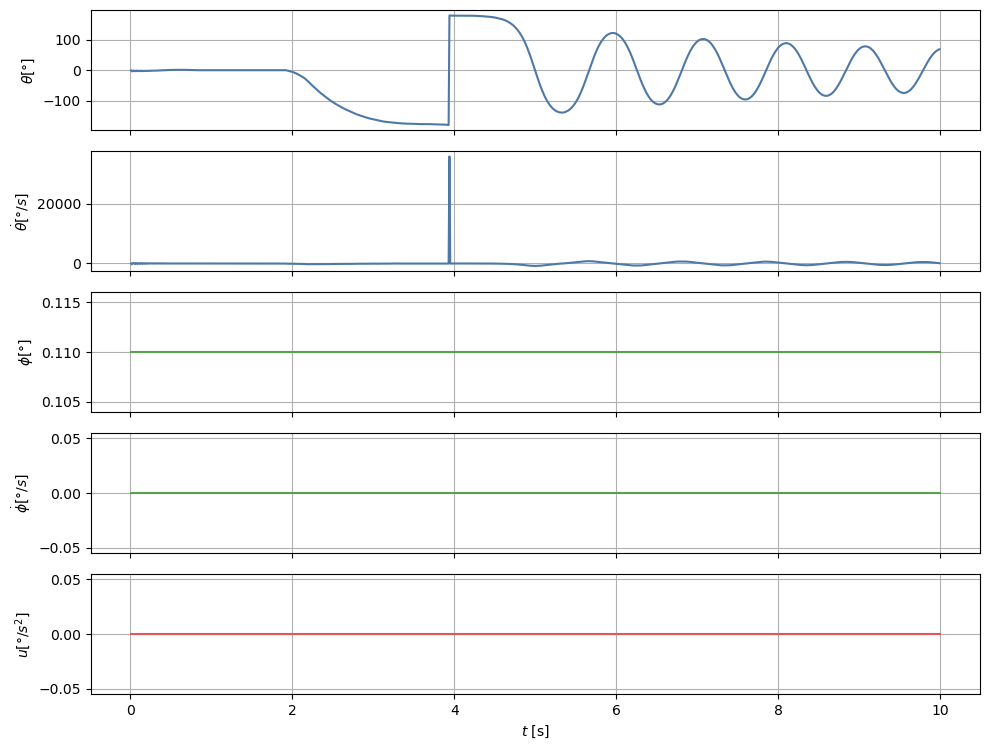

In [7]:
time_plot(logCAL)

A,d,f,phi,off = [139.5444627    0.20387511   0.8825778   -3.14159265  -2.1890921 ]


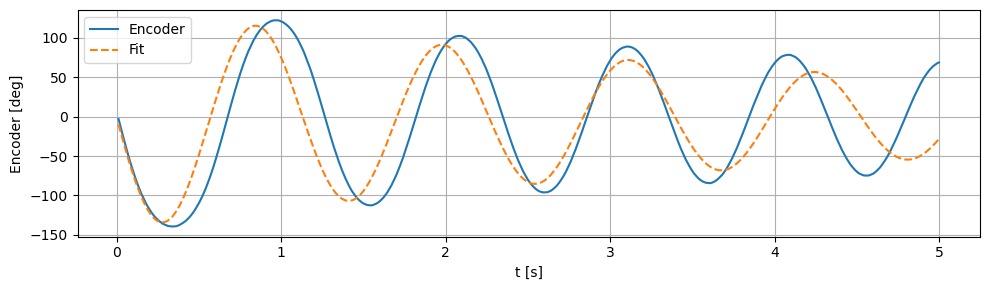

In [8]:
fit_enc_plot(logCAL, t_start=t_start, A = 200, d=0.1, f = 0.5, phi=-0.3, off=0)

In [9]:
# Determine pendulum damping
d = 0.15

# From data sheet
m = 0.016     # Pendulum mass
l = 0.235    # Pendulum length
r = 0.110    # Pendulum radial length

# Giving rotational damping b
b = 2 / 3 * d * m * l**2
print(b)

8.835999999999999e-05


# Testrun 1

In [10]:
# Calibrate encoder (needs 1 second, keep pendulum still!)
p.enc_calibration(180)

In [11]:
p.set_home()

In [12]:
log = []
p.start()
try:
    while True:
        msg = p.read_telemetry()
        t_now = msg["t"]

        # nur sammeln (kein print für maximale Echtzeit)
        print(msg)
        log.append(msg)

        if t_now == 2.0:
            p.set_speed(100)
        elif t_now == 2.2:
            p.set_speed(-100)
        elif t_now == 2.5:
            p.set_speed(0)
        elif t_now == 3.0:
            p.stop()
            break
        #elif msg["stp_pos"] < 90 or msg["stp_pos"] > 270:
        #    p.stop()
        #    break

finally:
    p.stop()  # safety

{'t': 0.01, 'enc_pos': -1.2, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.02, 'enc_pos': -2.1, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.03, 'enc_pos': -0.3, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.04, 'enc_pos': -1.2, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.05, 'enc_pos': -1.8, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.06, 'enc_pos': -0.6, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.07, 'enc_pos': -1.2, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.08, 'enc_pos': -1.8, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.09, 'enc_pos': -0.6, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.1, 'enc_pos': -1.2, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.11, 'enc_pos': -1.5, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.12, 'enc_pos': -0.6, 'stp_pos': 0.22, 'vel_set': 1.0}
{'t': 0.13, 'enc_pos': -1.2, 'stp_pos': 0.22, 'vel_set': 1.0}
{'t': 0.14, 'enc_pos': -1.2, 'stp_pos': 0.22, 'vel_set': 1.0}
{'t': 0.15, 'enc_pos': -0.6, 'stp_pos': 0.22, 'vel_set': 1.0}
{'t': 0.16, 'enc_pos': -1.2, 'stp_pos': 0.22, 'vel_set': 1.0}
{'t': 0.1

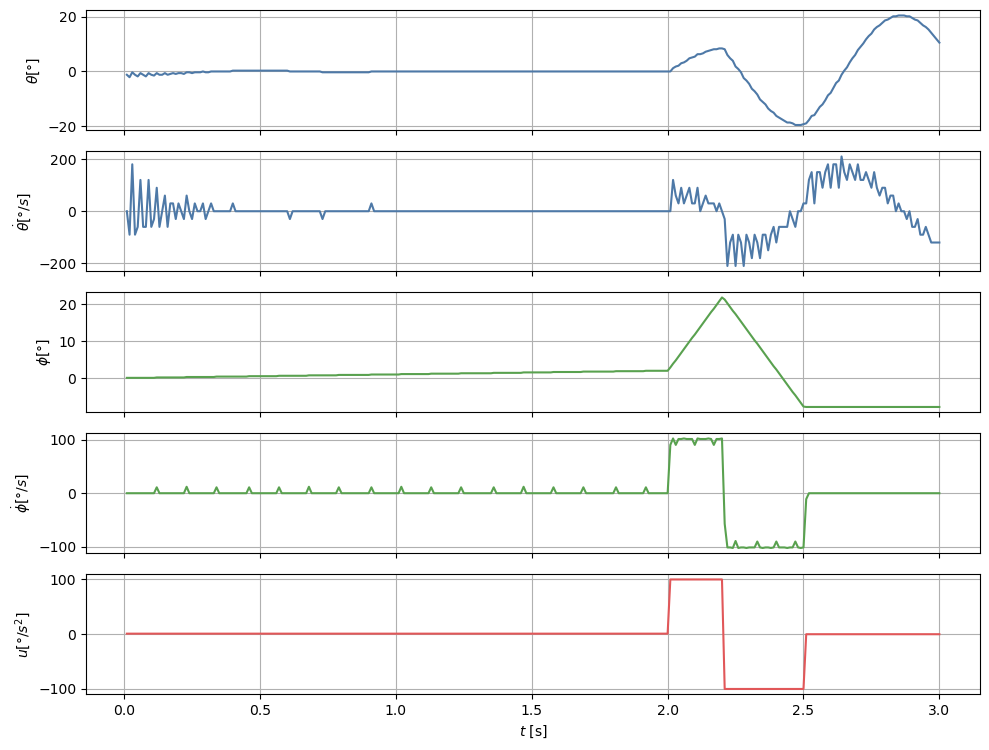

In [13]:
# Plotting
time_plot(log)

**PID**

In [249]:
p.stop()
p.set_home()

In [250]:
p.enc_calibration()

In [251]:
# PID
logPID = []
actionsPID = []
enc_set = 0   # Vertical position
dphi = 0       # Stepper start acceleration
Kp =250
Ki = 0
Kd = 0
I = 0.0

dphi_max = 300
p.start()
try:
    # first step to initialize
    while True:
        msg = p.read_telemetry()          # blockiert bis nächste Zeile
        logPID.append(msg)
        print(msg)

        t = msg["t"]
        enc = msg["enc_pos"]
        stp = msg["stp_pos"]

        # Get error
        error = enc_set - enc

        if len(logPID) == 1:   
            prev_t = t             # Skip first step to calculate dt and derivations
            prev_enc = enc
            prev_stp = stp
            prev_error = error
            continue
        elif len(logPID) == 2:
            dt = t - prev_t

        # Get derivations
        enc_dot = (enc - prev_enc) / dt
        stp_dot = (stp - prev_stp) / dt

        # Proportional (P)
        P = error

        # Integral (I)
        I += error * dt
        I = np.clip(I, -5.0, 5.0)  # anti-windup: Prevents extreme integral values for long integration times

        # Derivative (D)
        D = (error - prev_error) / dt

        # Calc set output
        u = Kp * P + Ki * I + Kd * D

        # But u is acceleration! Not speed!
        ddphi = u   # Angular acc for stepper rotation
        actionsPID.append(u)

        # Stepper needs velocity
        dphi += dt * ddphi
        dphi_set = float(np.clip(dphi, -dphi_max, dphi_max))
        p.set_speed(-dphi_set)

        prev_t = t
        prev_enc = enc
        prev_stp = stp
    
        if msg["stp_pos"] < -110 or msg["stp_pos"] > 110:
            p.stop()
            print("Stepper position limit!")
            break

        if msg["enc_pos"] < -30 or msg["enc_pos"] > 30:
            p.stop()
            print("Encoder position limit!")
            break

        if 20 < msg["t"]:
            p.stop()
            print("Time off!")
            break
        

finally:
    p.stop()  # safety


{'t': 0.01, 'enc_pos': 0.0, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.02, 'enc_pos': 1.2, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.03, 'enc_pos': -0.9, 'stp_pos': 0.11, 'vel_set': 3.0}
{'t': 0.04, 'enc_pos': -0.9, 'stp_pos': 0.11, 'vel_set': 0.75}
{'t': 0.05, 'enc_pos': 0.9, 'stp_pos': 0.11, 'vel_set': -1.5}
{'t': 0.06, 'enc_pos': -0.3, 'stp_pos': 0.11, 'vel_set': 0.75}
{'t': 0.07, 'enc_pos': -0.9, 'stp_pos': 0.11, 'vel_set': 0.0}
{'t': 0.08, 'enc_pos': 0.9, 'stp_pos': 0.0, 'vel_set': -2.25}
{'t': 0.09, 'enc_pos': 0.0, 'stp_pos': 0.0, 'vel_set': 0.0}
{'t': 0.1, 'enc_pos': -0.6, 'stp_pos': 0.0, 'vel_set': 0.0}
{'t': 0.11, 'enc_pos': 0.9, 'stp_pos': 0.0, 'vel_set': -1.5}
{'t': 0.12, 'enc_pos': 0.3, 'stp_pos': 0.0, 'vel_set': 0.75}
{'t': 0.13, 'enc_pos': -0.3, 'stp_pos': 0.0, 'vel_set': 1.5}
{'t': 0.14, 'enc_pos': 1.2, 'stp_pos': 0.0, 'vel_set': 0.75}
{'t': 0.15, 'enc_pos': 0.3, 'stp_pos': 0.11, 'vel_set': 3.75}
{'t': 0.16, 'enc_pos': -0.3, 'stp_pos': 0.11, 'vel_set': 4.5}
{'t': 0.17, 'enc

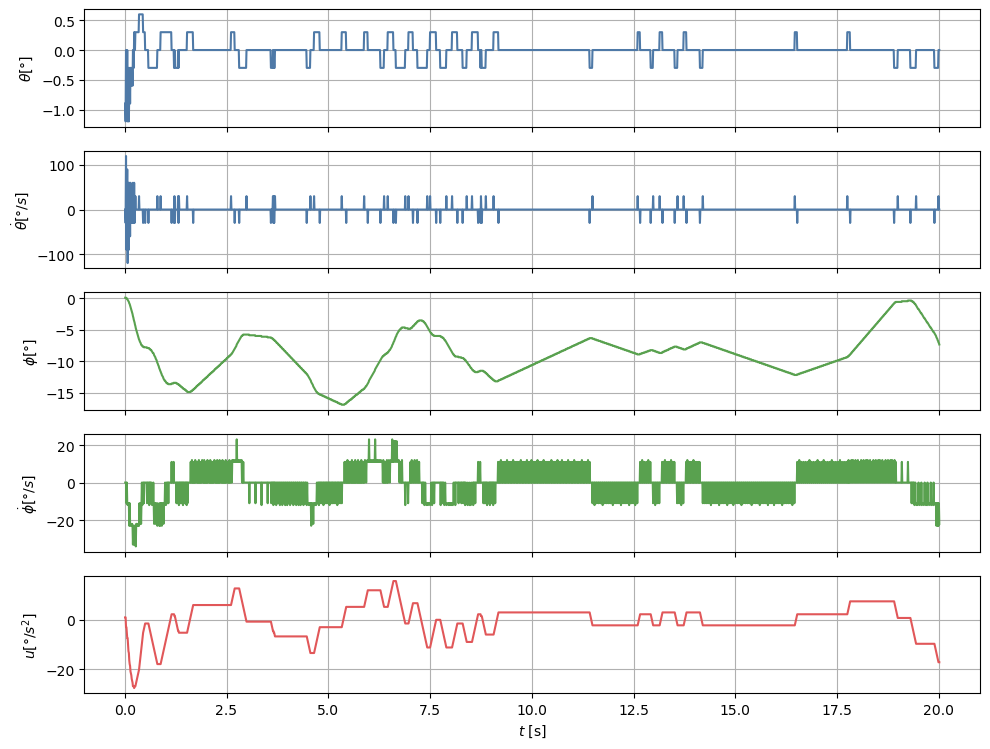

In [241]:
# Plotting
time_plot(logPID,actionsPID, set=enc_set, title="PID tuned inverted pendulum_2")

**LQR**

In [9]:
# Pendulum parameters
g = 9.81    # Gravitation
l = 0.235    # Pendulum length
r = 0.110    # Pendulum hook length
m = 0.0208 * l/(r+l)    # Pendulum mass

# Determine pendulum damping
d = 0.15

# Giving rotational damping b
b = 2 / 3 * d * m * l**2

# b from calibration!

A = np.array([
    [0, 1, 0, 0],
    [3*g/(2*l), -3*b/(m*l**2), 0, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 0]
])

B = np.array([
    [0],
    [-3*r/(2*l)],
    [0],
    [1]
])

Q = np.diag([100, 1, 10000, 1])   # ...
R = np.array([[100]])       # ...

# Solve Riccati equation
P = solve_continuous_are(A, B, Q, R)

# LQR-Gain vector
K_lqr = np.linalg.inv(R) @ B.T @ P
print(K_lqr)

[[-310.71168787  -38.52819287  -10.           -7.04914894]]


In [19]:
p.stop()
p.set_home()


In [20]:
p.enc_calibration()

In [21]:
# NEEEEW

# LQR
logLQR = []
actionsLQR = []
enc_set = 0   # Vertical position
p.start()
try:
    while True:
        msg = p.read_telemetry()          # blockiert bis nächste Zeile
        logLQR.append(msg)
        print(msg)

        t = msg["t"]
        enc = msg["enc_pos"]
        stp = msg["stp_pos"]

        if len(logLQR) == 1:   
            prev_t = t             # Skip first step to calculate dt and derivations
            prev_enc = enc
            prev_stp = stp
            du_stp = 0.0
            continue
        elif len(logLQR) == 2:
            dt = t - prev_t

        # Get derivations (in deg/s)
        denc = (enc - prev_enc) / dt
        dstp = (stp - prev_stp) / dt

        # state vector x = [theta, dtheta, phi, dphi]
        # We have to do some kinematics here, because it is a rotary pendulum
        theta = enc * deg2rad
        dtheta = denc * deg2rad
        phi = stp * deg2rad
        dphi = dstp * deg2rad

        # State vector (in rad, rad/s, rad and rad/s)
        x = np.array([
            [theta],
            [dtheta],
            [phi],
            [dphi],
        ])

        u = float((K_lqr @ x).item())
        
        # But u is translational acceleration! Not rotational stepper speed!
        
        ddu_stp = u * rad2deg
        #actionsLQR.append[ddu_stp]

        # Stepper takes velocity
        du_stp += dt * ddu_stp
        du_set = float(np.clip(du_stp, -300, 300))
        p.set_speed(-du_set)

        prev_t = t
        prev_enc = enc
        prev_stp = stp
    
        if msg["stp_pos"] < -110 or msg["stp_pos"] > 110:
            p.stop()
            print("Stepper position limit!")
            break

        if msg["enc_pos"] < -30 or msg["enc_pos"] > 30:
            p.stop()
            print("Encoder position limit!")
            break

        if 1000 < msg["t"]:
            p.stop()
            print("Time off!")
            break
finally:
    p.stop()



{'t': 0.01, 'enc_pos': -2.1, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.02, 'enc_pos': -1.5, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.03, 'enc_pos': -3.3, 'stp_pos': 0.34, 'vel_set': 18.47}
{'t': 0.04, 'enc_pos': -3.3, 'stp_pos': -0.11, 'vel_set': -59.48}
{'t': 0.05, 'enc_pos': -1.5, 'stp_pos': -0.9, 'vel_set': -72.92}
{'t': 0.06, 'enc_pos': -2.7, 'stp_pos': -1.12, 'vel_set': -13.89}
{'t': 0.07, 'enc_pos': -3.3, 'stp_pos': -1.8, 'vel_set': -70.17}
{'t': 0.08, 'enc_pos': -1.5, 'stp_pos': -2.81, 'vel_set': -108.52}
{'t': 0.09, 'enc_pos': -2.1, 'stp_pos': -3.37, 'vel_set': -51.23}
{'t': 0.1, 'enc_pos': -3.0, 'stp_pos': -4.16, 'vel_set': -85.15}
{'t': 0.11, 'enc_pos': -1.2, 'stp_pos': -5.4, 'vel_set': -135.14}
{'t': 0.12, 'enc_pos': -1.2, 'stp_pos': -6.19, 'vel_set': -78.79}
{'t': 0.13, 'enc_pos': -2.1, 'stp_pos': -7.09, 'vel_set': -88.71}
{'t': 0.14, 'enc_pos': -0.6, 'stp_pos': -8.44, 'vel_set': -136.96}
{'t': 0.15, 'enc_pos': 0.3, 'stp_pos': -9.34, 'vel_set': -91.4}
{'t': 0.16, 'enc_pos': 

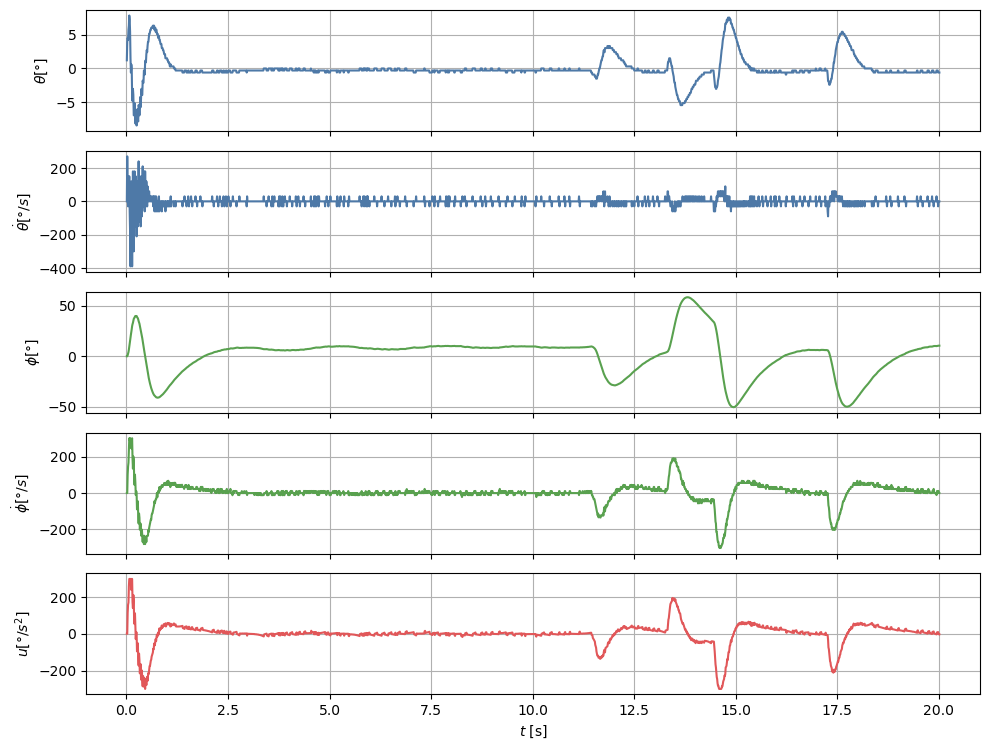

In [61]:
time_plot(logLQR, actionsLQR, set=0, title="LQR tuned inverted pendulum_2")

# LQI

Problem is: Position is not 0, we need an Integrator!

In [64]:
# TODO: Fill out matrix! (Parameters M, m, c_cart, c_rot, l, g are already pre-defined, just use them directly!)
A_new = np.array([
    [0, 1, 0, 0, 0],
    [3*g/(2*l), -3*b/(m*l**2), 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 0, -1, 0, 0]
])

B_new = np.array([
    [0],
    [-3*r/(2*l)],
    [0],
    [1],
    [0]
])


# Punishing [theta, theta_dot, pos, vel, int]
Q_new = np.diag([100, 1, 10000, 1, 500000])   # ...
R_new = np.array([[100]])       # ...

# Solve Riccati equation
P_new = solve_continuous_are(A_new, B_new, Q_new, R_new)

# LQR-Gain vector
K_lqi = np.linalg.inv(R_new) @ B_new.T @ P_new
print(K_lqi)

[[-528.33662048  -62.84005319  -55.06270105  -20.73167112   70.71067812]]


In [246]:
p.stop()
p.set_home()

In [247]:
p.enc_calibration()

{'t': 0.01, 'enc_pos': -0.9, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.02, 'enc_pos': -2.1, 'stp_pos': 0.11, 'vel_set': 1.0}
{'t': 0.03, 'enc_pos': 0.0, 'stp_pos': -0.67, 'vel_set': -86.44}
{'t': 0.04, 'enc_pos': 0.9, 'stp_pos': -0.56, 'vel_set': 28.98}
{'t': 0.05, 'enc_pos': -1.5, 'stp_pos': 0.11, 'vel_set': 92.25}
{'t': 0.06, 'enc_pos': -1.8, 'stp_pos': 0.45, 'vel_set': -52.54}
{'t': 0.07, 'enc_pos': 0.0, 'stp_pos': -0.23, 'vel_set': -73.61}
{'t': 0.08, 'enc_pos': -0.9, 'stp_pos': -0.11, 'vel_set': 25.27}
{'t': 0.09, 'enc_pos': -1.8, 'stp_pos': -0.45, 'vel_set': -33.62}
{'t': 0.1, 'enc_pos': 0.3, 'stp_pos': -1.46, 'vel_set': -106.99}
{'t': 0.11, 'enc_pos': 0.6, 'stp_pos': -1.58, 'vel_set': 4.79}
{'t': 0.12, 'enc_pos': -1.2, 'stp_pos': -1.35, 'vel_set': 23.43}
{'t': 0.13, 'enc_pos': -0.3, 'stp_pos': -2.03, 'vel_set': -92.04}
{'t': 0.14, 'enc_pos': 0.6, 'stp_pos': -2.59, 'vel_set': -52.34}
{'t': 0.15, 'enc_pos': -0.6, 'stp_pos': -2.59, 'vel_set': -5.72}
{'t': 0.16, 'enc_pos': 0.3, 'stp_

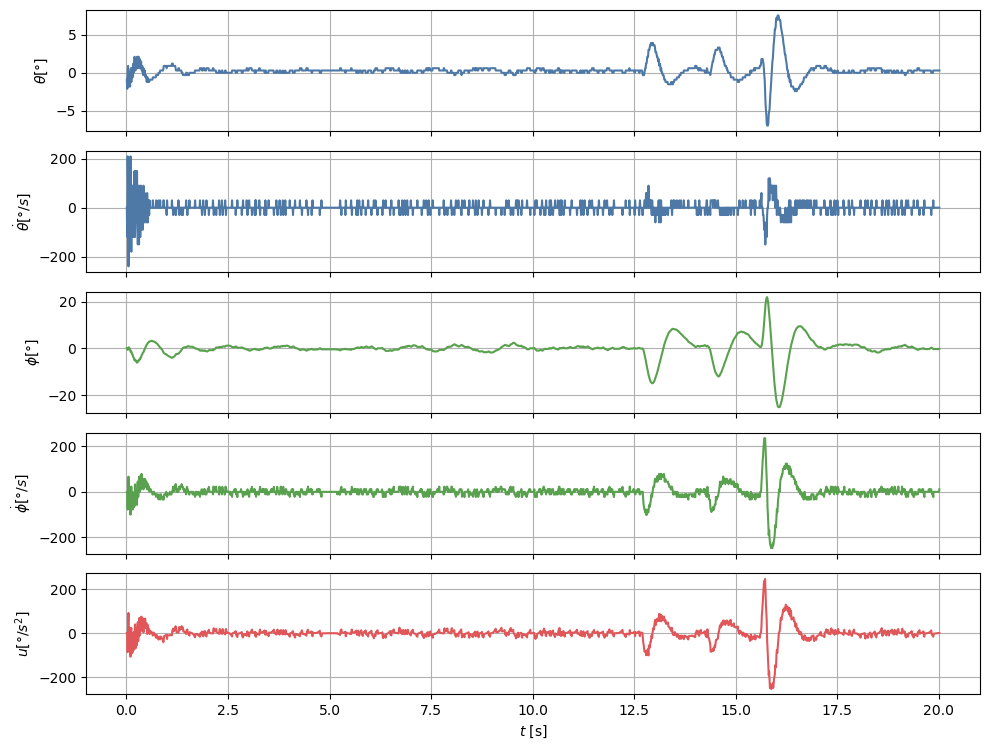

In [ ]:
# LQI
logLQI = []
actionsLQI = []
p.start()
try:
    while True:
        msg = p.read_telemetry()          # blockiert bis nächste Zeile
        logLQI.append(msg)
        print(msg)

        t = msg["t"]
        enc = msg["enc_pos"]
        stp = msg["stp_pos"]

        if len(logLQI) == 1:   
            prev_t = t             # Skip first step to calculate dt and derivations
            prev_enc = enc
            prev_stp = stp
            du_stp = 0.0
            z = 0.0                 # New integrator
            continue
        elif len(logLQI) == 2:
            dt = t - prev_t

        # Get derivations (in deg/s)
        denc = (enc - prev_enc) / dt
        dstp = (stp - prev_stp) / dt


        # state vector x = [theta, theta_dot, pos, vel, int]
        # We have to do some kinematics here, because it is a rotary pendulum
        theta = enc * deg2rad
        dtheta = denc * deg2rad
        phi = stp * deg2rad
        dphi = dstp * deg2rad
        z -= phi * dt                    # New for LQI: Get integral
        z = np.clip(z, -10, 10)

        # State vector (in rad, rad/s, m and m/s)
        x = np.array([
            [theta],
            [dtheta],
            [phi],
            [dphi],
            [z]
        ])

        u = float((K_lqi @ x).item())
        
        # But u is translational acceleration! Not rotational stepper speed!
        ddu_stp = u * rad2deg
        #actionsLQI.append[ddu_stp]

        du_stp += dt * ddu_stp
        du_set = float(np.clip(du_stp, -300, 300))
        p.set_speed(-du_set)

        prev_t = t
        prev_enc = enc
        prev_stp = stp
    
        if msg["stp_pos"] < -110 or msg["stp_pos"] > 110:
            p.stop()
            print("Stepper position limit!")
            break

        if msg["enc_pos"] < -30 or msg["enc_pos"] > 30:
            p.stop()
            print("Encoder position limit!")
            break

        if 1000 < msg["t"]:
            p.stop()
            print("Time off!")
            break
finally:
    p.stop()

time_plot(logLQI, title="SSC tuned inverted pendulum_2")

# Competition

We mode from $\phi=0°$ to $\phi=30°$ to $\phi=-30°$ and back to the start. The state score defines the offset from the desired value as rms, the action score the RMS of the inout $u$ from $0$.

In [75]:
# Helper functions

def rms(err):
    if not err:
        return float("nan")
    return np.sqrt(sum(e*e for e in err) / len(err))

def calc_score(log):
    t       = [m["t"] for m in log]         # seconds
    enc     = [m["enc_pos"] for m in log]   # phi
    stp     = [m["stp_pos"] for m in log]   # theta 
    vel_set = [m["vel_set"] for m in log]   # action

    if not log:
        print("Your score: n/a (empty log)")
        return {
            "theta_score": float("nan"),
            "phi_score": float("nan"),
            "total_score": float("nan"),
        }

    t_end = t[-1]

    # Sollwert-Profil für phi:
    # - ab 5s:  +30
    # - ab 10s: -30
    # - letzte 5s: 0
    # Annahme: vor 5s ist Sollwert 0 (falls du was anderes willst, hier ändern)
    phi_ref = []
    for ti in t:
        if ti >= t_end - 5.0:
            ref = 0.0
        elif ti >= 10.0:
            ref = -30.0
        elif ti >= 5.0:
            ref = 30.0
        else:
            ref = 0.0
        phi_ref.append(ref)

    # RMS gegenüber Sollwert
    phi_err    = [p - r for p, r in zip(stp, phi_ref)]
    theta_err  = [th - 0.0 for th in enc]
    action_err = [a  - 0.0 for a  in vel_set]

    phi_score    = rms(phi_err)
    theta_score  = rms(theta_err)
    total_score = theta_score + 1/10 * phi_score

    print(f"Your scores (RMS): phi={phi_score:.3f}, theta={theta_score:.3f}, total={total_score:.3f}")

    return {
        "theta_score": theta_score,
        "phi_score": phi_score,
        "total_score": total_score
    }

In [76]:
# Punishing [theta, theta_dot, pos, vel, int] // If no integrator is wanted, we set int=0
Q_COMP = np.diag([10, 10, 1000, 1, 0])   # ...
R_COMP = np.array([[10]])       # ...

# Solve Riccati equation
P_COMP = solve_continuous_are(A_new, B_new, Q_COMP, R_COMP)

# LQR-Gain vector
K_COMP = np.linalg.inv(R_COMP) @ B_new.T @ P_COMP
print(K_COMP)
    

[[-3.17977920e+02 -3.78331600e+01 -1.00000000e+01 -7.17007901e+00
   3.43044126e-20]]


In [81]:
p.stop()
p.set_home()

In [80]:
p.enc_calibration()

In [82]:
# COMP
logCOMP = []
actionsCOMP = []
phiRef = 0
pos = 0     # Pose of the pendulum
p.start()
try:
    while True:
        msg = p.read_telemetry()          # blockiert bis nächste Zeile
        logCOMP.append(msg)
        #print(msg)

        t = msg["t"]
        enc = msg["enc_pos"]
        stp = msg["stp_pos"]

        if len(logCOMP) == 1:   
            prev_t = t             # Skip first step to calculate dt and derivations
            prev_enc = enc
            prev_stp = stp
            du_stp = 0.0
            z = 0.0                 # New integrator
            continue
        elif len(logCOMP) == 2:
            dt = t - prev_t

        # Get derivations (in deg/s)
        denc = (enc - prev_enc) / dt
        dstp = (stp - prev_stp) / dt

        # Get new states
        if t >= 5 and pos == 0:
            phiRef = 30 * deg2rad
            pos = 1     # First position
            z = 0       # Reset buffer for integrator
        if t>=10 and pos == 1:
            phiRef = - 30 * deg2rad
            pos = 2     # Next position
            z = 0       # Reset buffer for integrator

        if t >= 15 and pos == 2:
            phiRef = 0
            pos = 3
            z = 0       # Reset buffer for integrator


        # state vector x = [theta, theta_dot, pos, vel, int]
        # We have to do some kinematics here, because it is a rotary pendulum
        theta = enc * deg2rad
        dtheta = denc * deg2rad
        phi = stp * deg2rad - phiRef
        dphi = dstp * deg2rad
        z -= phi * dt                    # New for LQI: Get integral
        z = np.clip(z, -10, 10)

        # State vector (in rad, rad/s, m and m/s)
        x = np.array([
            [theta],
            [dtheta],
            [phi],
            [dphi],
            [z]
        ])

        u = float((K_lqi @ x).item())
        
        # But u is translational acceleration! Not rotational stepper speed!
        ddu_stp = u * rad2deg
        #actionsLQI.append[ddu_stp]

        du_stp += dt * ddu_stp
        du_set = float(np.clip(du_stp, -300, 300))
        p.set_speed(-du_set)

        prev_t = t
        prev_enc = enc
        prev_stp = stp
    
        if msg["stp_pos"] < -110 or msg["stp_pos"] > 110:
            p.stop()
            print("Stepper position limit!")
            break

        if msg["enc_pos"] < -30 or msg["enc_pos"] > 30:
            p.stop()
            print("Encoder position limit!")
            break

        if 20 < msg["t"]:
            p.stop()
            print("Time off!")
            break
finally:
    p.stop()

Time off!


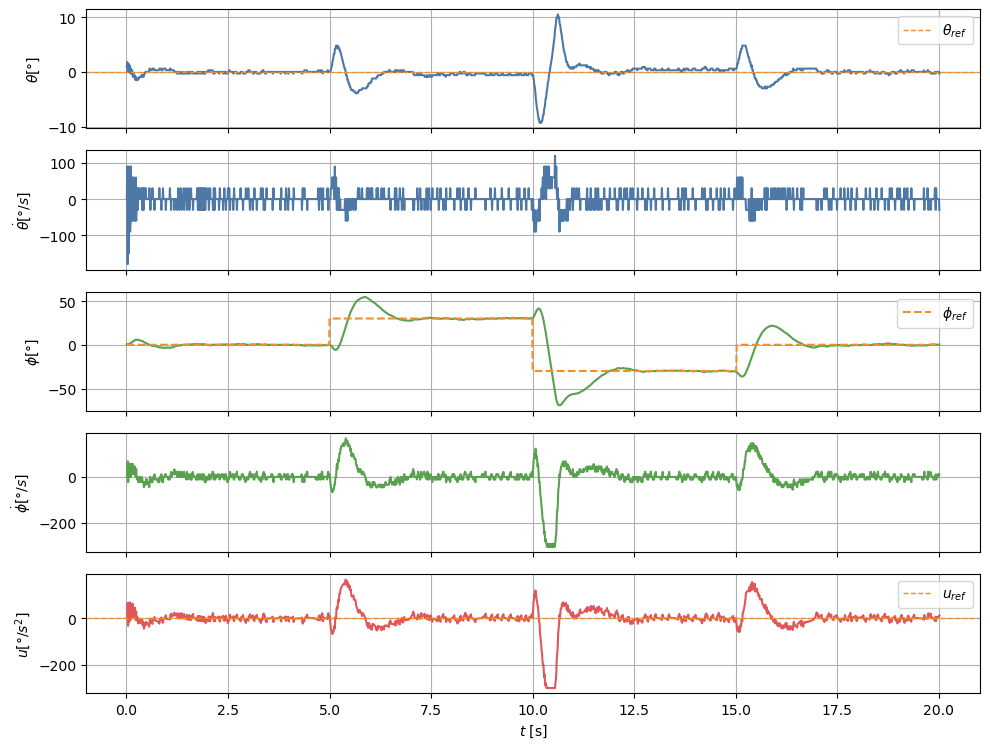

In [83]:
time_plot(logCOMP, title="SSC in competition", competition=True)

In [84]:
calc_score(logCOMP)

Your scores (RMS): phi=13.180, theta=1.656, total=2.974


{'theta_score': 1.655548120777495,
 'phi_score': 13.179844625329467,
 'total_score': 2.973532583310442}